In [1]:
import numpy as np, pandas as pd
from sklearn.datasets import make_moons

In [2]:
from mlxtend.plotting import plot_decision_regions

In [3]:
from tensorflow.keras.layers import Dense, Input, BatchNormalization
from tensorflow.keras import Sequential

2026-04-18 12:42:07.040135: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 12:42:07.614647: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-18 12:42:07.614770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-18 12:42:07.621108: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-18 12:42:07.669028: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 12:42:07.673182: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [4]:
import matplotlib.pyplot as plt
plt.style.use('default')

In [5]:
X, y = make_moons(n_samples=400, noise=0.2, random_state=None)

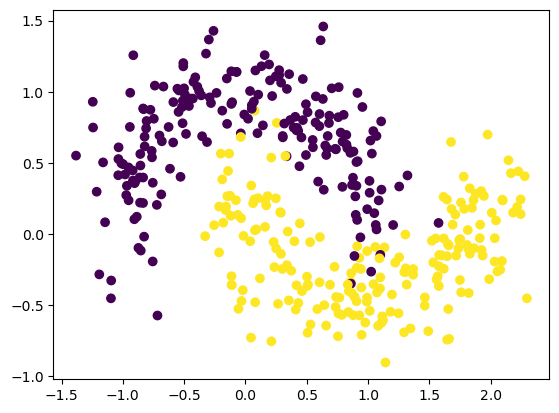

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping 

In [8]:
CALLBACK = EarlyStopping(
monitor='val_loss',
min_delta=0.00001,
patience=20,
verbose=1,
mode='auto',
baseline=None,
restore_best_weights=False
)

### without batch normalizatoin

In [9]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [10]:
model = Sequential()

In [11]:
model.add(Input(shape=(2, )))
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(1, activation='sigmoid'))

In [12]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics = ['accuracy'])

In [13]:
history = model.fit(X, y, epochs=100, validation_split=0.2, verbose=1, callbacks=CALLBACK)

2026-04-18 12:42:33.260133: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type CPU is enabled.


Epoch 1/100


10/10 [==============================] - 13s 523ms/step - loss: 0.4283 - accuracy: 0.7719 - val_loss: 0.3057 - val_accuracy: 0.8500
Epoch 2/100
10/10 [==============================] - 2s 153ms/step - loss: 0.2806 - accuracy: 0.8719 - val_loss: 0.3221 - val_accuracy: 0.8500
Epoch 3/100
10/10 [==============================] - 1s 98ms/step - loss: 0.2839 - accuracy: 0.8625 - val_loss: 0.3338 - val_accuracy: 0.8500
Epoch 4/100
10/10 [==============================] - 1s 153ms/step - loss: 0.2702 - accuracy: 0.8719 - val_loss: 0.2950 - val_accuracy: 0.8500
Epoch 5/100
10/10 [==============================] - 2s 168ms/step - loss: 0.2536 - accuracy: 0.8750 - val_loss: 0.3114 - val_accuracy: 0.8750
Epoch 6/100
10/10 [==============================] - 1s 75ms/step - loss: 0.2535 - accuracy: 0.8750 - val_loss: 0.2950 - val_accuracy: 0.8625
Epoch 7/100
10/10 [==============================] - 1s 136ms/step - loss: 0.2501 - accuracy: 0.8750 - val_loss: 0.2910 - val_accuracy: 0.8625
Epoch 8/100


9600/9600 [==============================] - 187s 19ms/step


<Axes: >

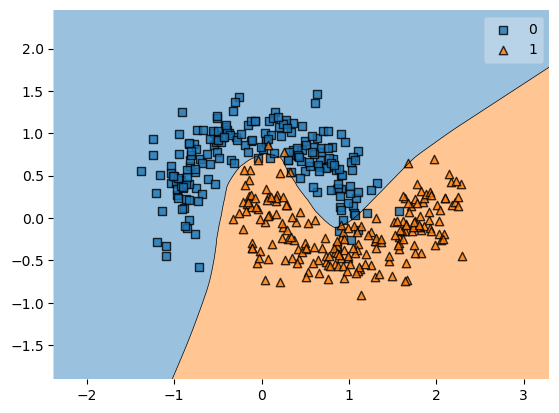

In [15]:
plot_decision_regions(X, y, clf = model)

### with batch normalization

In [16]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [17]:
model_1 = Sequential()

In [18]:
model_1.add(Input(shape=(2,)))
model_1.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model_1.add(BatchNormalization())
model_1.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model_1.add(BatchNormalization())
model_1.add(Dense(1, activation='sigmoid'))

In [19]:
model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               384       
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 18049 (70.50 KB)
Trainable params: 17537 (

In [20]:
model_1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [21]:
history_1 = model_1.fit(X, y, epochs=100, validation_split=0.2, verbose=1, callbacks=CALLBACK)

Epoch 1/100
10/10 [==============================] - 7s 150ms/step - loss: 0.5175 - accuracy: 0.7312 - val_loss: 0.4382 - val_accuracy: 0.8625
Epoch 2/100
10/10 [==============================] - 0s 43ms/step - loss: 0.2844 - accuracy: 0.8813 - val_loss: 0.3479 - val_accuracy: 0.8625
Epoch 3/100
10/10 [==============================] - 1s 136ms/step - loss: 0.1346 - accuracy: 0.9531 - val_loss: 0.3395 - val_accuracy: 0.8250
Epoch 4/100
10/10 [==============================] - 1s 148ms/step - loss: 0.1406 - accuracy: 0.9438 - val_loss: 0.3592 - val_accuracy: 0.8375
Epoch 5/100
10/10 [==============================] - 2s 168ms/step - loss: 0.1456 - accuracy: 0.9625 - val_loss: 0.3631 - val_accuracy: 0.8500
Epoch 6/100
10/10 [==============================] - 1s 76ms/step - loss: 0.1012 - accuracy: 0.9750 - val_loss: 0.3528 - val_accuracy: 0.8625
Epoch 7/100
10/10 [==============================] - 1s 58ms/step - loss: 0.1147 - accuracy: 0.9563 - val_loss: 0.3446 - val_accuracy: 0.8750
Ep

9600/9600 [==============================] - 115s 12ms/step


<Axes: >

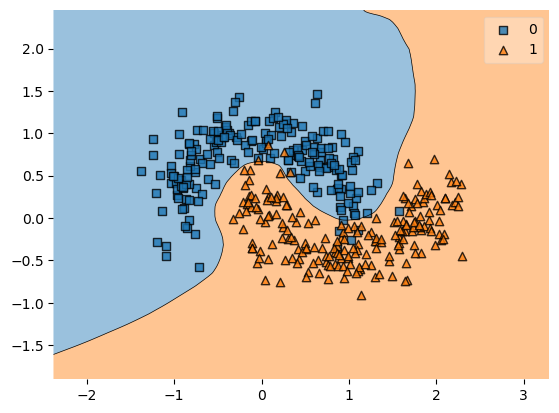

In [22]:
plot_decision_regions(X, y, clf = model_1)

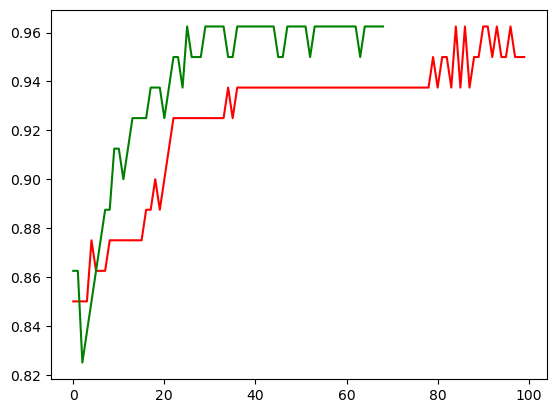

In [25]:
plt.plot(history.history['val_accuracy'], color='red')
plt.plot(history_1.history['val_accuracy'], color='green')
plt.show()

## so here we can see batchnormalizatoin has achieved more accuracy in less epochs than without batchnormalization.